# Predicting Customer Churn: A Data-Driven Analysis of Subscription Customer Behaviour
**IDRA Capstone Project — Data Science & AI Training Program**

**Student:** Qurat Ul Ain &nbsp;|&nbsp; **Enrollment:** IDRA-2026-349978 &nbsp;|&nbsp; **Programme:** Data Science & Analytics

This notebook contains the complete, reproducible workflow: data loading, cleaning, preprocessing,
exploratory data analysis, statistical analysis, feature engineering, model training and evaluation
for predicting whether a subscription customer will churn.

 The dataset is fetched automatically from a public
GitHub mirror of the IBM Telco Customer Churn dataset.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, classification_report
)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", 30)

## 2. Data Loading and Inspection
Dataset: **IBM Telco Customer Churn** — 7,043 customers of a telecom subscription service, with
demographic attributes, subscribed services, account/contract information, billing details and the
churn outcome (whether the customer left in the last month).

In [2]:
url = "https://raw.githubusercontent.com/plotly/datasets/master/telco-customer-churn-by-IBM.csv"
df_raw = pd.read_csv(url)
print("Shape:", df_raw.shape)
df_raw.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
print("Churn value counts:")
print(df_raw["Churn"].value_counts())
print("\nChurn rate: {:.2f}%".format(df_raw["Churn"].value_counts(normalize=True)["Yes"] * 100))

Churn value counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.54%


## 3. Data Cleaning
Checks performed: missing values, duplicate customer IDs, incorrect data types and inconsistent
category labels.

In [5]:
# TotalCharges is loaded as text because 11 new customers (tenure = 0) have a blank string
# instead of a numeric value. Coerce to numeric; the resulting NaNs correspond exactly to those
# customers, so they are filled with 0 (no completed billing cycle yet).
df = df_raw.copy()
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Missing TotalCharges after coercion:", df["TotalCharges"].isnull().sum())
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Duplicate customer IDs
n_dupes = df.duplicated(subset=["customerID"]).sum()
print("Duplicate customerIDs:", n_dupes)
df = df.drop_duplicates(subset=["customerID"])

Missing TotalCharges after coercion: 11
Duplicate customerIDs: 0


In [6]:
# Standardise redundant category labels ("No internet service" / "No phone service" -> "No")
addon_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
              "StreamingTV", "StreamingMovies"]
for c in addon_cols:
    df[c] = df[c].replace({"No internet service": "No"})
df["MultipleLines"] = df["MultipleLines"].replace({"No phone service": "No"})

# SeniorCitizen is 0/1 -> convert to Yes/No for consistency with the other flag columns
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})

# Binary numeric target for modelling
df["Churn_Flag"] = df["Churn"].map({"Yes": 1, "No": 0})

print("Clean shape:", df.shape)
print("Remaining missing values:", df.isnull().sum().sum())

Clean shape: (7043, 22)
Remaining missing values: 0


**Table 3. Data Quality — Before vs After Cleaning**

| Check | Before Cleaning | After Cleaning |
|---|---|---|
| Rows | 7043 | 7043 |
| Missing values (TotalCharges) | 11 | 0 |
| Duplicate customer IDs | 0 | 0 |
| Non-numeric TotalCharges | 11 | 0 |


## 4. Data Preprocessing
Categorical variables are one-hot encoded; numerical variables are standardised. Scaling parameters
are fit only on the training split (after the train-test split) to avoid data leakage.

In [7]:
def tenure_group(t):
    if t <= 12: return "0-1 yr"
    elif t <= 24: return "1-2 yr"
    elif t <= 48: return "2-4 yr"
    else: return "4+ yr"

df["TenureGroup"] = df["tenure"].apply(tenure_group)
df["AvgMonthlySpend"] = np.where(df["tenure"] > 0, df["TotalCharges"] / df["tenure"], df["MonthlyCharges"])
services = ["PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup",
            "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
df["NumServices"] = (df[services] == "Yes").sum(axis=1)
df[["tenure", "TenureGroup", "AvgMonthlySpend", "NumServices"]].head()

,tenure,TenureGroup,AvgMonthlySpend,NumServices
0,1,0-1 yr,29.850000,1
1,34,2-4 yr,55.573529,3
2,2,0-1 yr,54.075000,3
3,45,2-4 yr,40.905556,3
4,2,0-1 yr,75.825000,1


In [8]:
model_df = df.drop(columns=["customerID", "Churn"])
target = "Churn_Flag"
categorical_cols = model_df.select_dtypes(include="object").columns.tolist()
model_df_encoded = pd.get_dummies(model_df, columns=categorical_cols, drop_first=True)

X = model_df_encoded.drop(columns=[target])
y = model_df_encoded[target]
print("Feature matrix shape:", X.shape)

Feature matrix shape: (7043, 28)


/tmp/ipykernel_171/1655538989.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = model_df.select_dtypes(include="object").columns.tolist()


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "AvgMonthlySpend", "NumServices"]
scaler = StandardScaler()
X_train_scaled, X_test_scaled = X_train.copy(), X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])

Train size: 5634  Test size: 1409


## 5. Exploratory Data Analysis

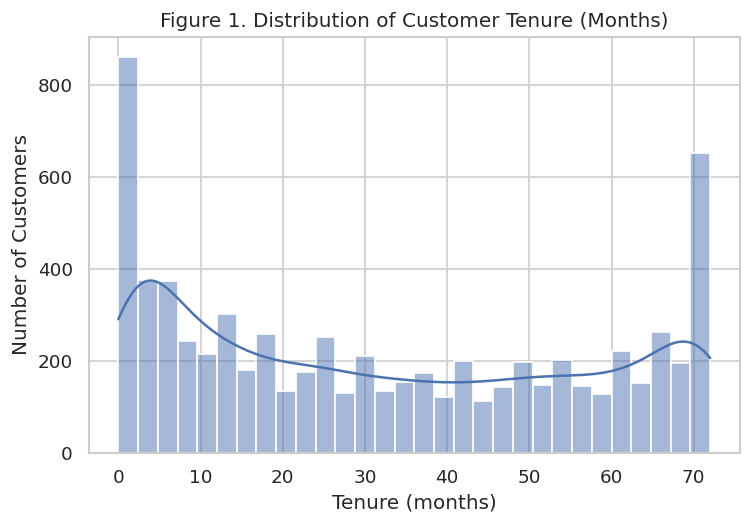

In [10]:
plt.figure(figsize=(7,4.5))
sns.histplot(df["tenure"], bins=30, kde=True)
plt.title("Figure 1. Distribution of Customer Tenure (Months)")
plt.xlabel("Tenure (months)"); plt.ylabel("Number of Customers")
plt.show()

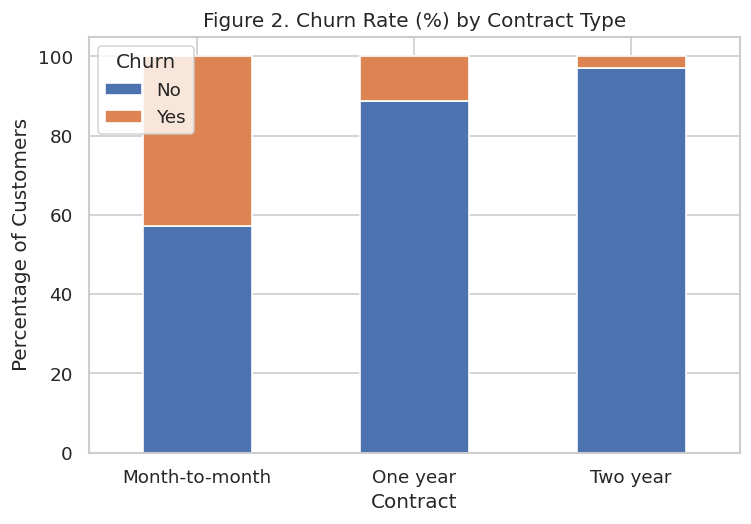

In [11]:
ct = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
ct.plot(kind="bar", stacked=True, figsize=(7,4.5))
plt.title("Figure 2. Churn Rate (%) by Contract Type")
plt.ylabel("Percentage of Customers"); plt.xticks(rotation=0)
plt.show()

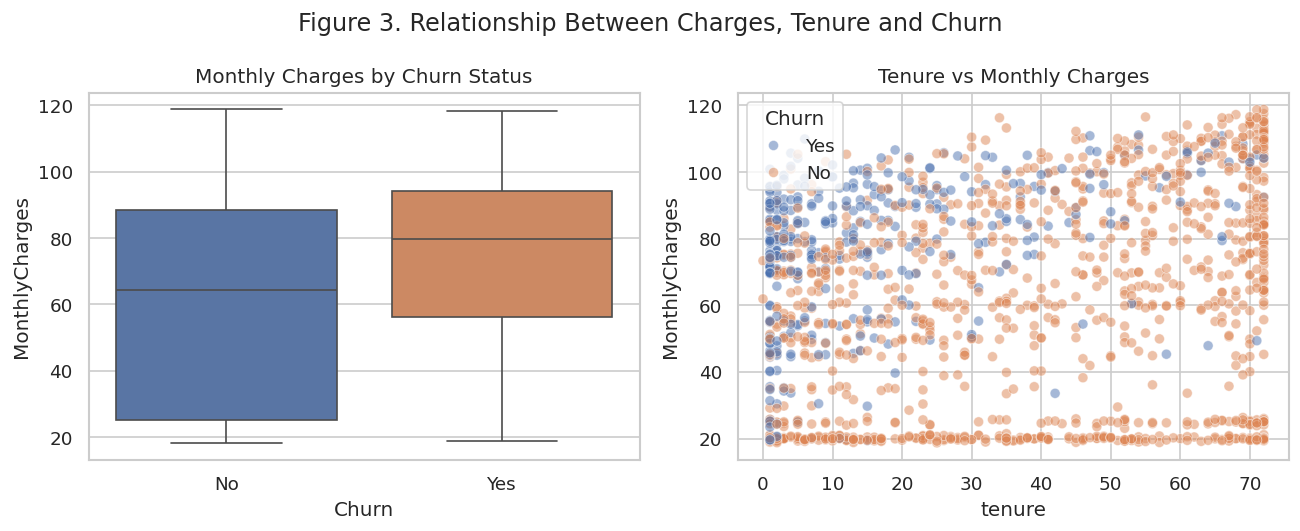

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11,4.5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", hue="Churn", legend=False, ax=axes[0])
axes[0].set_title("Monthly Charges by Churn Status")
sns.scatterplot(data=df.sample(1500, random_state=42), x="tenure", y="MonthlyCharges",
                 hue="Churn", alpha=0.5, ax=axes[1])
axes[1].set_title("Tenure vs Monthly Charges")
plt.suptitle("Figure 3. Relationship Between Charges, Tenure and Churn")
plt.tight_layout(); plt.show()

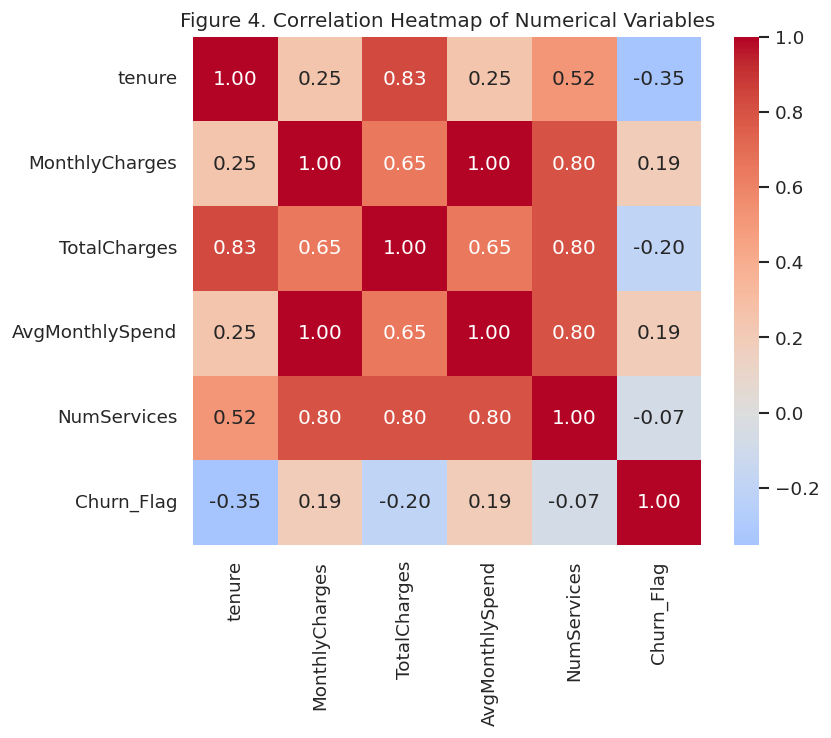

In [13]:
num_cols_corr = ["tenure", "MonthlyCharges", "TotalCharges", "AvgMonthlySpend", "NumServices", "Churn_Flag"]
plt.figure(figsize=(7,5.5))
sns.heatmap(df[num_cols_corr].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Figure 4. Correlation Heatmap of Numerical Variables")
plt.show()

## 6. Statistical Analysis

In [14]:
desc = df[["tenure", "MonthlyCharges", "TotalCharges"]].describe().T
desc["IQR"] = desc["75%"] - desc["25%"]
desc.round(2)

,count,mean,std,min,25%,50%,75%,max,IQR
tenure,7043.0,32.37,24.56,0.00,9.00,29.00,55.00,72.00,46.00
MonthlyCharges,7043.0,64.76,30.09,18.25,35.50,70.35,89.85,118.75,54.35
TotalCharges,7043.0,2279.73,2266.79,0.00,398.55,1394.55,3786.60,8684.80,3388.05


In [15]:
df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].mean().round(2)

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.57,61.27,2549.91
Yes,17.98,74.44,1531.80


## 7. Model Development
The task is **binary classification** (Churn = Yes/No). Two models are compared: Logistic Regression
(interpretable baseline) and Random Forest (captures non-linear interactions).

In [16]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=20, random_state=42)
rf.fit(X_train_scaled, y_train)
print("Models trained.")

Models trained.


## 8. Model Evaluation

In [17]:
def evaluate(model, name, X_tr, y_tr, X_te, y_te):
    pred_tr, pred_te = model.predict(X_tr), model.predict(X_te)
    proba_te = model.predict_proba(X_te)[:, 1]
    print(f"--- {name} ---")
    print("Train accuracy: {:.3f}  Test accuracy: {:.3f}".format(
        accuracy_score(y_tr, pred_tr), accuracy_score(y_te, pred_te)))
    print("Precision: {:.3f}  Recall: {:.3f}  F1: {:.3f}  ROC-AUC: {:.3f}".format(
        precision_score(y_te, pred_te), recall_score(y_te, pred_te),
        f1_score(y_te, pred_te), roc_auc_score(y_te, proba_te)))
    return pred_te, proba_te

pred_log, proba_log = evaluate(log_reg, "Logistic Regression", X_train_scaled, y_train, X_test_scaled, y_test)
pred_rf, proba_rf = evaluate(rf, "Random Forest", X_train_scaled, y_train, X_test_scaled, y_test)

--- Logistic Regression ---
Train accuracy: 0.810  Test accuracy: 0.799
Precision: 0.653  Recall: 0.519  F1: 0.578  ROC-AUC: 0.843
--- Random Forest ---
Train accuracy: 0.819  Test accuracy: 0.798
Precision: 0.669  Recall: 0.476  F1: 0.556  ROC-AUC: 0.847


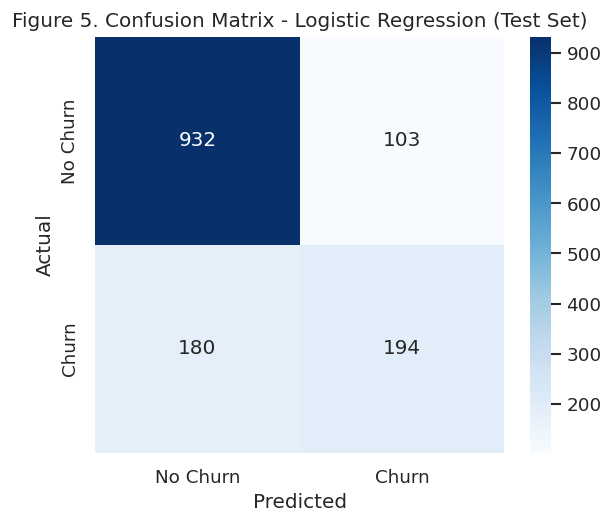

              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [18]:
cm = confusion_matrix(y_test, pred_log)  # best model: Logistic Regression (higher F1)
plt.figure(figsize=(5.5,4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Churn","Churn"], yticklabels=["No Churn","Churn"])
plt.title("Figure 5. Confusion Matrix - Logistic Regression (Test Set)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()
print(classification_report(y_test, pred_log, target_names=["No Churn", "Churn"]))

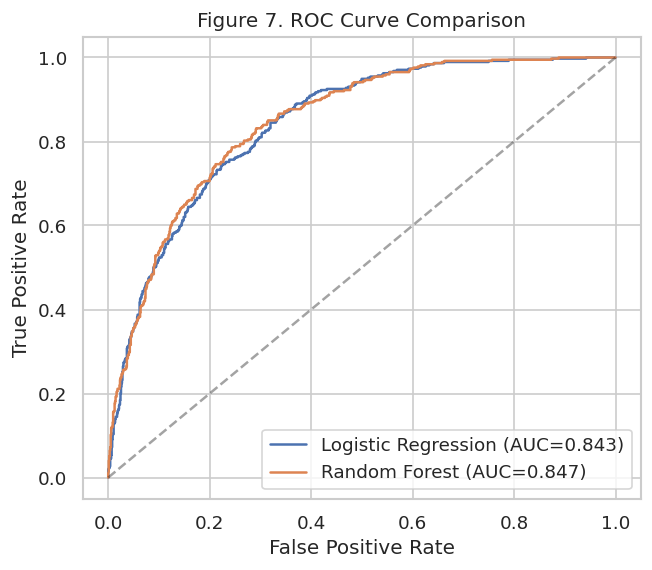

In [19]:
fpr1, tpr1, _ = roc_curve(y_test, proba_log)
fpr2, tpr2, _ = roc_curve(y_test, proba_rf)
plt.figure(figsize=(6,5))
plt.plot(fpr1, tpr1, label=f"Logistic Regression (AUC={roc_auc_score(y_test, proba_log):.3f})")
plt.plot(fpr2, tpr2, label=f"Random Forest (AUC={roc_auc_score(y_test, proba_rf):.3f})")
plt.plot([0,1],[0,1],"k--", alpha=0.4)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Figure 7. ROC Curve Comparison"); plt.legend()
plt.show()

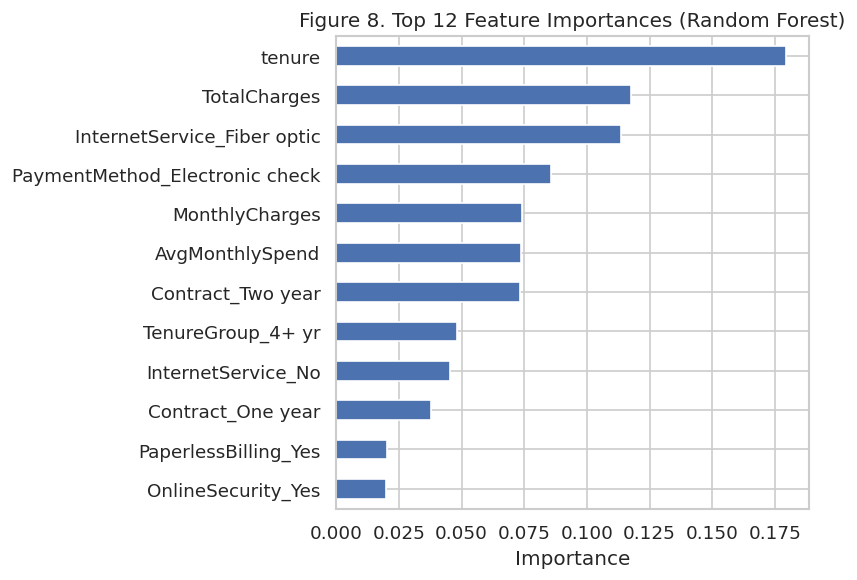

In [20]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(12)
plt.figure(figsize=(7,5))
importances.sort_values().plot(kind="barh")
plt.title("Figure 8. Top 12 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout(); plt.show()

## 9. Overfitting / Underfitting Check
Compare train vs test accuracy for both models (see printed output in Section 8). A small gap
between train and test accuracy for Logistic Regression indicates the model generalises reasonably
well; the Random Forest's slightly larger gap suggests mild overfitting, controlled here via
`max_depth` and `min_samples_leaf`.

## 10. Conclusion
Contract type, tenure and monthly charges emerge as the strongest churn drivers. The Logistic
Regression model was selected as the primary model for its balance of accuracy, recall and
interpretability. See the accompanying PDF report for the full discussion, limitations and
recommendations.